In [32]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("tension.db")

df = pd.read_sql_query(
    "SELECT uuid, name, frames FROM climbs WHERE layout_id = 10 LIMIT 10",
    conn
)
df

,uuid,name,frames
0,0A70BF5C001641D3BBE59E11528A7251,Hermes,p466r8p477r6p480r6p485r8p490r6p492r7p498r5p500...
1,0DEA33F171FE4DEF85A5E284758A9040,Tremolo,p305r5p462r6p480r6p484r8p490r6p498r8p515r8p532...
2,0EC1F6C1CC0343F7BD139C43D8EBD1A3,Travercity,p344r6p352r6p366r8p369r6p379r8p382r6p410r8p420...
3,190B4AE30516447E856228F5907A113B,Stilts,p307r6p308r6p309r6p329r8p428r8p437r8p462r6p463...
4,1EDFA870269B424D8EC46E0A77461485,Pre Blast,p304r8p305r5p348r8p445r8p447r6p462r6p466r8p471...
5,2639A269B0AE444CBF3B7653B25A0562,Moondance,p306r8p470r8p476r8p485r8p692r6p697r5p722r5p725...
6,3923A16F0AA14B73B8ACA331BB80504D,Wholeberry,p439r5p447r8p476r8p478r8p480r6p484r8p485r8p500...
7,3ea329d3be7b4f4490eecc3f44253a0c,Pet Rock with Googley Eyes,p435r8p490r6p492r7p547r8p585r6p689r8p692r6p697...
8,4759E07E543F4B4A914F16182E370972,Wayward Son,p306r8p470r8p476r8p485r8p692r6p697r5p722r5p725...
9,5F518D6F481E4DDA81491CF28AEB8789,Clean,p304r8p308r6p309r6p344r6p354r6p358r8p366r8p443...


In [33]:
print(df['frames'].iloc[0])

p466r8p477r6p480r6p485r8p490r6p492r7p498r5p500r6p504r8p507r6p509r6p514r8


In [34]:
pd.read_sql_query("SELECT * FROM placement_roles", conn)

,id,product_id,position,name,full_name,led_color,screen_color
0,1,4,1,start,Start,00FF00,00DD00
1,3,4,3,finish,Finish,FF0000,FF0000
2,4,4,4,foot,Foot Only,FF00FF,FF00FF
3,5,5,1,start,Start,00FF00,00DD00
4,7,5,3,finish,Finish,FF0000,FF0000
5,8,5,4,foot,Foot Only,FF00FF,FF00FF
6,2,4,2,middle,Middle,0000FF,0066FF
7,6,5,2,middle,Middle,0000FF,0066FF


In [35]:
ROLES = {5: 'start', 6: 'hand', 7: 'finish', 8: 'foot'}
COLORS = {5: '#00DD00', 6: '#0066FF', 7: '#FF0000', 8: '#FF00FF'}

In [36]:
print(pd.read_sql_query("SELECT * FROM placements LIMIT 5", conn))
print(pd.read_sql_query("SELECT * FROM holes LIMIT 5", conn))

   id  layout_id  hole_id  set_id  default_placement_role_id
0   1          9        2       8                          3
1   2          9       10       8                          3
2   3          9      317       8                          1
3   4          9      325       8                          1
4   5          9      320       8                          1
   id  product_id  name   x    y  mirrored_hole_id  mirror_group
0   1           4  A,18   8  152                11             0
1   2           4  B,18  16  152                10             0
2   3           4  C,18  24  152                 9             0
3   4           4  D,18  32  152                 8             0
4   5           4  E,18  40  152                 7             0


In [37]:
holds = pd.read_sql_query("""
    SELECT p.id AS placement_id, h.x, h.y, h.name
    FROM placements p
    JOIN holes h ON p.hole_id = h.id
    WHERE p.layout_id = 10
""", conn)

print(len(holds))
print(holds['placement_id'].min(), holds['placement_id'].max())
holds.head()

690
304 1491


,placement_id,x,y,name
0,672,-64,4,"-64,4"
1,1433,-64,12,"-64,12"
2,673,-64,20,"-64,20"
3,419,-64,28,"-64,28"
4,420,-64,36,"-64,36"


In [38]:
import re

def decode_frames(frames):
    pairs = re.findall(r'p(\d+)r(\d+)', frames)
    return [(int(p), int(r)) for p, r in pairs]

decode_frames(df['frames'].iloc[0])

[(466, 8),
 (477, 6),
 (480, 6),
 (485, 8),
 (490, 6),
 (492, 7),
 (498, 5),
 (500, 6),
 (504, 8),
 (507, 6),
 (509, 6),
 (514, 8)]

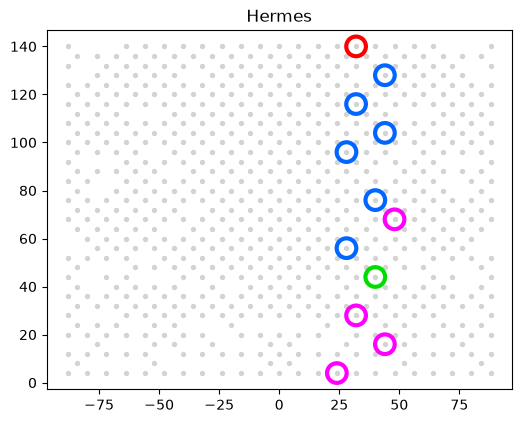

In [39]:
import matplotlib.pyplot as plt

COLORS = {5: '#00DD00', 6: '#0066FF', 7: '#FF0000', 8: '#FF00FF'}
coords = holds.set_index('placement_id')

def plot_climb(frames, title=''):
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.scatter(holds['x'], holds['y'], s=8, c='lightgray')
    for pid, role in decode_frames(frames):
        row = coords.loc[pid]
        ax.scatter(row['x'], row['y'], s=200, facecolors='none',
                   edgecolors=COLORS[role], linewidths=3)
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.show()

plot_climb(df['frames'].iloc[0], df['name'].iloc[0])

In [40]:
data = pd.read_sql_query("""
    SELECT c.uuid, c.name, c.frames,
           s.angle, s.difficulty_average, s.ascensionist_count, s.quality_average
    FROM climbs c
    JOIN climb_stats s ON c.uuid = s.climb_uuid
    WHERE c.layout_id = 10 AND s.ascensionist_count >= 5
""", conn)

print(len(data))
data.head()

15853


,uuid,name,frames,angle,difficulty_average,ascensionist_count,quality_average
0,0A70BF5C001641D3BBE59E11528A7251,Hermes,p466r8p477r6p480r6p485r8p490r6p492r7p498r5p500...,25,13.0870,23,2.73913
1,0A70BF5C001641D3BBE59E11528A7251,Hermes,p466r8p477r6p480r6p485r8p490r6p492r7p498r5p500...,35,12.0909,11,2.63636
2,0A70BF5C001641D3BBE59E11528A7251,Hermes,p466r8p477r6p480r6p485r8p490r6p492r7p498r5p500...,40,13.8421,38,2.55263
3,0DEA33F171FE4DEF85A5E284758A9040,Tremolo,p305r5p462r6p480r6p484r8p490r6p498r8p515r8p532...,20,13.0000,23,2.78261
4,0DEA33F171FE4DEF85A5E284758A9040,Tremolo,p305r5p462r6p480r6p484r8p490r6p498r8p515r8p532...,25,12.9000,10,2.60000


In [41]:
print(data['angle'].value_counts().sort_index())
print(data['difficulty_average'].describe())
data['n_holds'] = data['frames'].apply(lambda f: len(decode_frames(f)))
print(data['n_holds'].describe())

angle
0       97
5       60
10     183
15     382
20     806
25     922
30    1534
35    1265
40    6465
45    2802
50     950
55     218
60     126
65      43
Name: count, dtype: int64
count    15853.000000
mean        19.103756
std          4.594363
min         10.000000
25%         15.764700
50%         18.993800
75%         22.800000
max         30.400000
Name: difficulty_average, dtype: float64
count    15853.000000
mean        11.327761
std          4.904790
min          3.000000
25%          9.000000
50%         11.000000
75%         13.000000
max        101.000000
Name: n_holds, dtype: float64


In [42]:
print(data['n_holds'].quantile([0.9, 0.95, 0.99, 0.995, 1.0]))
print((data['n_holds'] > 20).sum())

0.900     15.0
0.950     18.0
0.990     24.0
0.995     31.0
1.000    101.0
Name: n_holds, dtype: float64
310


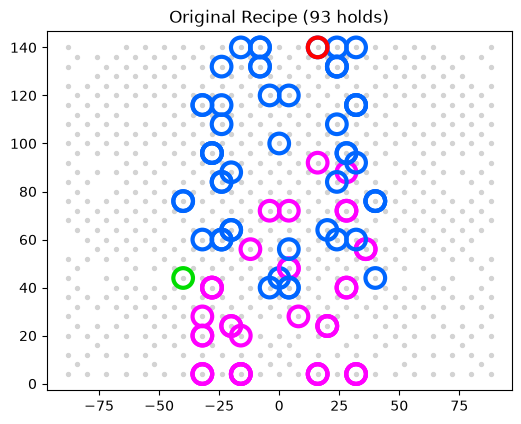

In [43]:
long_climb = data[data['n_holds'] > 40].iloc[0]
plot_climb(long_climb['frames'], f"{long_climb['name']} ({long_climb['n_holds']} holds)")

In [44]:
data = data[data['n_holds'] <= 20].copy()
print(len(data))

15543


In [45]:
PAD, BOS, EOS = 0, 1, 2
ROLE_IDS = [5, 6, 7, 8]

placement_ids = sorted(holds['placement_id'].tolist())

# token index -> meaning
role_to_token = {r: 3 + i for i, r in enumerate(ROLE_IDS)}          # 3..6
hold_to_token = {p: 7 + i for i, p in enumerate(placement_ids)}     # 7..696

token_to_role = {v: k for k, v in role_to_token.items()}
token_to_hold = {v: k for k, v in hold_to_token.items()}

VOCAB_SIZE = 7 + len(placement_ids)
print(VOCAB_SIZE)

697


In [46]:
def encode(frames):
    tokens = [BOS]
    for pid, role in decode_frames(frames):
        tokens.append(hold_to_token[pid])
        tokens.append(role_to_token[role])
    tokens.append(EOS)
    return tokens

def decode(tokens):
    pairs = []
    for i in range(1, len(tokens) - 1, 2):
        if tokens[i] in token_to_hold and tokens[i+1] in token_to_role:
            pairs.append((token_to_hold[tokens[i]], token_to_role[tokens[i+1]]))
    return pairs

In [47]:
original = data['frames'].iloc[0]
assert decode(encode(original)) == decode_frames(original)
print("round trip ok")

round trip ok


In [48]:
for f in data['frames']:
    assert decode(encode(f)) == decode_frames(f)
print("all round trips ok")

all round trips ok


In [49]:
import numpy as np

MAX_LEN = 2 + 2 * 20   # BOS + 20 holds × 2 tokens + EOS

def pad(tokens):
    return tokens + [PAD] * (MAX_LEN - len(tokens))

sequences = np.array([pad(encode(f)) for f in data['frames']])
print(sequences.shape)

(15543, 42)


In [50]:
angles = (data['angle'].values / 70.0).astype(np.float32)
grades = (data['difficulty_average'].values / 40.0).astype(np.float32)

In [51]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
idx_train, idx_val = next(gss.split(sequences, groups=data['uuid']))

print(len(idx_train), len(idx_val))

14029 1514


In [52]:
train_ids = set(data['uuid'].iloc[idx_train])
val_ids = set(data['uuid'].iloc[idx_val])
print(len(train_ids & val_ids), "climbs in both")

0 climbs in both


In [60]:
def to_features(frames, angle):
    vec = np.zeros(len(placement_ids) + 1, dtype=np.float32)
    for pid, role in decode_frames(frames):
        vec[hold_to_token[pid] - 7] = 1.0
    vec[-1] = angle / 70.0
    return vec

X = np.array([to_features(f, a) for f, a in zip(data['frames'], data['angle'])])
y = data['difficulty_average'].values

X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
print(X_train.shape)

(14029, 691)


In [54]:
from sklearn.metrics import mean_absolute_error

baseline = np.full_like(y_val, y_train.mean())
print("baseline MAE:", mean_absolute_error(y_val, baseline))

baseline MAE: 3.90192793517542


In [55]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(max_iter=300)
model.fit(X_train, y_train)
print("model MAE:", mean_absolute_error(y_val, model.predict(X_val)))

model MAE: 1.5642798318318825


In [56]:
preds = model.predict(X_val)
errors = np.abs(preds - y_val)
print("within 1 grade:", (errors < 1).mean())
print("within 2 grades:", (errors < 2).mean())

within 1 grade: 0.4002642007926024
within 2 grades: 0.7166446499339498


In [57]:
def to_features_v2(frames, angle):
    n = len(placement_ids)
    vec = np.zeros(n * 4 + 2, dtype=np.float32)
    holds_used = decode_frames(frames)
    for pid, role in holds_used:
        vec[(hold_to_token[pid] - 7) * 4 + (role - 5)] = 1.0
    vec[-2] = angle / 70.0
    vec[-1] = len(holds_used) / 20.0
    return vec

In [58]:
X2 = np.array([to_features_v2(f, a) for f, a in zip(data['frames'], data['angle'])])

model2 = HistGradientBoostingRegressor(max_iter=300)
model2.fit(X2[idx_train], y_train)
preds2 = model2.predict(X2[idx_val])

print("MAE:", mean_absolute_error(y_val, preds2))
errors2 = np.abs(preds2 - y_val)
print("within 1:", (errors2 < 1).mean())
print("within 2:", (errors2 < 2).mean())

MAE: 1.467101804263086
within 1: 0.4346103038309115
within 2: 0.726552179656539


In [61]:
def geo_features(frames, angle):
    pairs = decode_frames(frames)
    xs = np.array([coords.loc[p]['x'] for p, _ in pairs], dtype=float)
    ys = np.array([coords.loc[p]['y'] for p, _ in pairs], dtype=float)
    hand_ys = np.array([coords.loc[p]['y'] for p, r in pairs if r in (5, 6, 7)], dtype=float)
    hand_ys.sort()
    gaps = np.diff(hand_ys) if len(hand_ys) > 1 else np.array([0.0])
    return np.array([
        angle / 70.0,
        len(pairs),
        ys.max() - ys.min(),      # vertical span
        xs.max() - xs.min(),      # horizontal span
        gaps.mean(),              # average vertical gap between hands
        gaps.max(),               # biggest reach
        len(hand_ys),             # number of hands
        len(pairs) - len(hand_ys) # number of feet
    ], dtype=np.float32)

In [62]:
Xg = np.array([geo_features(f, a) for f, a in zip(data['frames'], data['angle'])])

# geometry alone — 8 features, no hold identity at all
mg = HistGradientBoostingRegressor(max_iter=300)
mg.fit(Xg[idx_train], y_train)
pg = mg.predict(Xg[idx_val])
print("geo only MAE:", mean_absolute_error(y_val, pg))
print("geo only within 1:", (np.abs(pg - y_val) < 1).mean())

geo only MAE: 2.2095899653718156
geo only within 1: 0.2919418758256275


In [63]:
X3 = np.hstack([X2, Xg])
m3 = HistGradientBoostingRegressor(max_iter=300)
m3.fit(X3[idx_train], y_train)
p3 = m3.predict(X3[idx_val])
print("combined MAE:", mean_absolute_error(y_val, p3))
print("combined within 1:", (np.abs(p3 - y_val) < 1).mean())

combined MAE: 1.3447353101337622
combined within 1: 0.4385733157199472
